In [1]:
import os

# Ensure the kernel loads the modern CUDA toolkit DLLs first (avoid old Anaconda NVRTC 11.2)
CUDA_BIN = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.2\bin\x64"
if os.path.isdir(CUDA_BIN):
    os.add_dll_directory(CUDA_BIN)

# Put CUDA toolkit path first and drop base Anaconda Library\bin if present.
# This prevents loading nvrtc64_112_0.dll from base env.
path_entries = os.environ.get("PATH", "").split(";")
filtered = [p for p in path_entries if "anaconda3\\library\\bin" not in p.lower()]
os.environ["PATH"] = CUDA_BIN + ";" + ";".join(filtered)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import time
from numba import cuda
import math

In [2]:
# X, _ = make_blobs(n_samples=1000000, n_features=100, centers=20, random_state=42)

# df = pd.DataFrame(X)
# df.to_csv("kmeans_benchmark_data.csv", index=False, header=False)
# print("Dataset generated successfully!")

In [2]:
X = pd.read_csv(r"C:\Users\elbaz\kmeans_benchmark_data.csv", header=None).values
Xs = StandardScaler().fit_transform(X)

ks = range(2, 30)
inertias = []
sils = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Xs)

    inertias.append(km.inertia_)

    sil_score = silhouette_score(Xs, labels, sample_size=20000, random_state=42)
    sils.append(sil_score)

    print(f"Finished k={k} | Inertia: {km.inertia_:.2f} | Silhouette: {sil_score:.4f}")

best_n_clusters = ks[int(np.argmax(sils))]
print(f"Best cluster size by silhouette: k={best_n_clusters}")

Finished k=2 | Inertia: 44078390.56 | Silhouette: 0.1008
Finished k=3 | Inertia: 40657523.69 | Silhouette: 0.1392
Finished k=4 | Inertia: 37900980.03 | Silhouette: 0.1726
Finished k=5 | Inertia: 35537580.05 | Silhouette: 0.2086
Finished k=6 | Inertia: 32077375.78 | Silhouette: 0.2597
Finished k=7 | Inertia: 30034102.29 | Silhouette: 0.2905
Finished k=8 | Inertia: 26926154.15 | Silhouette: 0.3393
Finished k=9 | Inertia: 24486457.96 | Silhouette: 0.3803
Finished k=10 | Inertia: 22314885.64 | Silhouette: 0.4192
Finished k=11 | Inertia: 19632772.97 | Silhouette: 0.4627
Finished k=12 | Inertia: 17673096.73 | Silhouette: 0.4972
Finished k=13 | Inertia: 15003689.19 | Silhouette: 0.5410
Finished k=14 | Inertia: 12978194.94 | Silhouette: 0.5785
Finished k=15 | Inertia: 11139560.58 | Silhouette: 0.6132
Finished k=16 | Inertia: 8923143.57 | Silhouette: 0.6572
Finished k=17 | Inertia: 7110636.53 | Silhouette: 0.6913
Finished k=18 | Inertia: 5152743.23 | Silhouette: 0.7323
Finished k=19 | Inertia: 

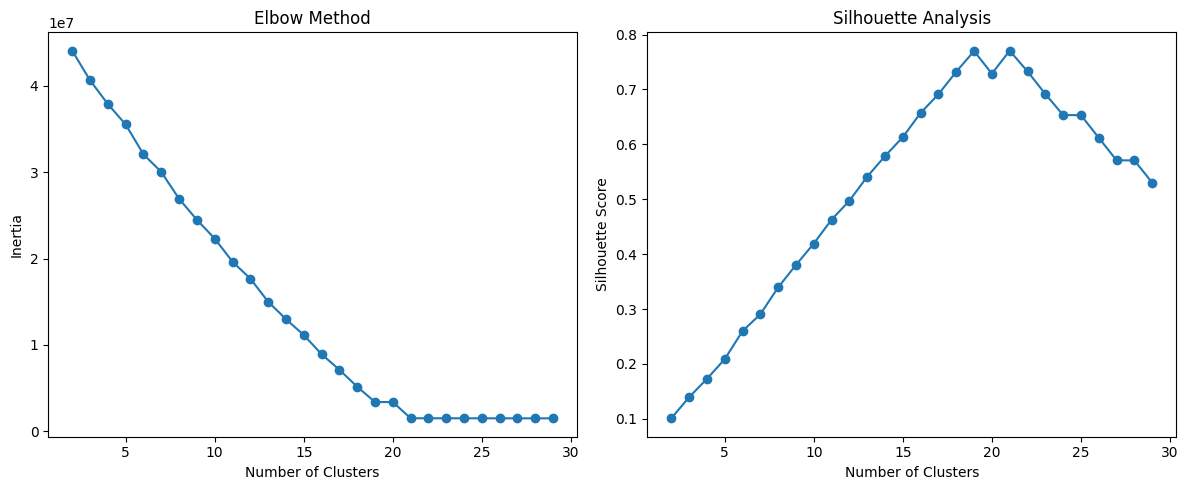

In [3]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ks, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(ks, sils, marker='o')
plt.title('Silhouette Analysis')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

In [4]:
from threadpoolctl import threadpool_limits

data = pd.read_csv(r"C:\Users\elbaz\kmeans_benchmark_data.csv", header=None).values
n_clusters = int(globals().get("best_n_clusters", 20))

# 1) Sequential CPU run (force 1 thread)
with threadpool_limits(limits=1):
    start_time = time.time()
    kmeans_cpu_seq = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_cpu_seq.fit(data)
    cpu_time_seq = time.time() - start_time

# 2) Parallel CPU run (use library defaults / available cores)
start_time = time.time()
kmeans_cpu_parallel = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_cpu_parallel.fit(data)
cpu_time_parallel = time.time() - start_time

# Keep legacy variable name for downstream cells
cpu_time = cpu_time_parallel

print(f"Using cluster size: k={n_clusters}")
print(f"CPU K-means (sequential, 1 thread): {cpu_time_seq:.4f} seconds")
print(f"CPU K-means (parallel, default threads): {cpu_time_parallel:.4f} seconds")
if cpu_time_parallel > 0:
    print(f"Parallel speedup vs sequential: {cpu_time_seq / cpu_time_parallel:.2f}x")

c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Using cluster size: k=21
CPU K-means (sequential, 1 thread): 3.2029 seconds
CPU K-means (parallel, default threads): 1.1424 seconds
Parallel speedup vs sequential: 2.80x


In [5]:
Xs = StandardScaler().fit_transform(data)

In [6]:
Xs.astype(np.float32).tofile("benchmark_data.bin")

In [20]:
import numpy as np
from numba import cuda
import time
import numba

MAX_CLUSTERS = 32
MAX_FEATURES = 128
MAX_CENTROID_SIZE = MAX_CLUSTERS * MAX_FEATURES

# Caches to avoid repeated host conversion and host->device copies across benchmark cells.
_KMEANS_GPU_CACHE = {
    "host_fp16": None,
    "host_fp16_key": None,
    "host_fp32": None,
    "host_fp32_key": None,
    "d_X_fp16": None,
    "d_X_fp16_key": None,
    "d_X_fp32": None,
    "d_X_fp32_key": None,
}


@cuda.jit(fastmath=True)
def reset_iteration_buffers_kernel(cluster_sums, cluster_counts, changes, n_clusters, n_features):
    idx = cuda.grid(1)
    flat_size = n_clusters * n_features

    if idx < flat_size:
        cluster_sums[idx] = 0.0

    if idx < n_clusters:
        cluster_counts[idx] = 0

    if idx == 0:
        changes[0] = 0


@cuda.jit(fastmath=True)
def init_assignments_kernel(assignments, n_samples):
    i = cuda.grid(1)
    if i < n_samples:
        assignments[i] = -1


@cuda.jit(fastmath=True)
def assign_and_accumulate_kernel(
    X,
    centroids,
    assignments,
    cluster_sums,
    cluster_counts,
    changes,
    n_samples,
    n_clusters,
    n_features,
    start_idx,
    work_items,
):
    shared_centroids = cuda.shared.array(MAX_CENTROID_SIZE, dtype=numba.float32)
    shared_sums = cuda.shared.array(MAX_CENTROID_SIZE, dtype=numba.float32)
    shared_counts = cuda.shared.array(MAX_CLUSTERS, dtype=numba.int32)

    tx = cuda.threadIdx.x
    bw = cuda.blockDim.x
    i = cuda.grid(1)
    stride = cuda.gridsize(1)
    flat_size = n_clusters * n_features

    for idx in range(tx, flat_size, bw):
        c = idx // n_features
        f = idx % n_features
        shared_centroids[idx] = centroids[c, f]
        shared_sums[idx] = 0.0

    if tx < n_clusters:
        shared_counts[tx] = 0

    cuda.syncthreads()

    for local_idx in range(i, work_items, stride):
        point_idx = start_idx + local_idx
        if point_idx >= n_samples:
            point_idx -= n_samples

        best_cluster = 0
        best_dist2 = numba.float32(1e30)

        for c in range(n_clusters):
            d2 = numba.float32(0.0)
            base = c * n_features

            for f in range(n_features):
                x_val = numba.float32(X[point_idx, f])
                diff = x_val - shared_centroids[base + f]
                d2 += diff * diff

            if d2 < best_dist2:
                best_dist2 = d2
                best_cluster = c

        old_cluster = assignments[point_idx]
        if old_cluster != best_cluster:
            cuda.atomic.add(changes, 0, 1)
        assignments[point_idx] = best_cluster

        cuda.atomic.add(shared_counts, best_cluster, 1)
        base = best_cluster * n_features
        for f in range(n_features):
            x_val = numba.float32(X[point_idx, f])
            cuda.atomic.add(shared_sums, base + f, x_val)

    cuda.syncthreads()

    for idx in range(tx, flat_size, bw):
        val = shared_sums[idx]
        if val != 0.0:
            cuda.atomic.add(cluster_sums, idx, val)

    if tx < n_clusters:
        count = shared_counts[tx]
        if count > 0:
            cuda.atomic.add(cluster_counts, tx, count)


@cuda.jit(fastmath=True)
def update_centroids_kernel(centroids, cluster_sums, cluster_counts, n_clusters, n_features):
    c = cuda.grid(1)

    if c < n_clusters:
        count = cluster_counts[c]
        if count > 0:
            inv_count = numba.float32(1.0) / numba.float32(count)
            base = c * n_features
            for f in range(n_features):
                centroids[c, f] = cluster_sums[base + f] * inv_count


def _prepare_host(X, precision):
    arr = np.asarray(X)
    key = (arr.__array_interface__["data"][0], arr.shape, arr.dtype.str)

    if precision == "fp32":
        if _KMEANS_GPU_CACHE["host_fp32_key"] != key:
            _KMEANS_GPU_CACHE["host_fp32"] = np.asfortranarray(arr, dtype=np.float32)
            _KMEANS_GPU_CACHE["host_fp32_key"] = key
        return _KMEANS_GPU_CACHE["host_fp32"]

    if _KMEANS_GPU_CACHE["host_fp16_key"] != key:
        _KMEANS_GPU_CACHE["host_fp16"] = np.asfortranarray(arr, dtype=np.float16)
        _KMEANS_GPU_CACHE["host_fp16_key"] = key
    return _KMEANS_GPU_CACHE["host_fp16"]


def _prepare_device_data(X_host, precision):
    key = (X_host.__array_interface__["data"][0], X_host.shape, X_host.dtype.str, X_host.strides)

    if precision == "fp32":
        if _KMEANS_GPU_CACHE["d_X_fp32_key"] != key:
            _KMEANS_GPU_CACHE["d_X_fp32"] = cuda.to_device(X_host)
            _KMEANS_GPU_CACHE["d_X_fp32_key"] = key
        return _KMEANS_GPU_CACHE["d_X_fp32"]

    if _KMEANS_GPU_CACHE["d_X_fp16_key"] != key:
        _KMEANS_GPU_CACHE["d_X_fp16"] = cuda.to_device(X_host)
        _KMEANS_GPU_CACHE["d_X_fp16_key"] = key
    return _KMEANS_GPU_CACHE["d_X_fp16"]


def kmeans_numba_optimized(
    X,
    n_clusters=20,
    max_iter=50,
    random_state=42,
    threads_per_block=256,
    convergence_check_every=4,
    mode="exact",
    sample_ratio=1.0,
    precision="fp16",
):
    n_clusters = int(n_clusters)
    if n_clusters > MAX_CLUSTERS:
        raise ValueError(f"n_clusters={n_clusters} exceeds MAX_CLUSTERS={MAX_CLUSTERS}")

    precision = str(precision).lower()
    if precision not in ("fp16", "fp32"):
        raise ValueError("precision must be 'fp16' or 'fp32'")

    X_host = _prepare_host(X, precision)
    n_samples = int(X_host.shape[0])
    n_features = int(X_host.shape[1])
    if n_features > MAX_FEATURES:
        raise ValueError(f"n_features={n_features} exceeds MAX_FEATURES={MAX_FEATURES}")

    if mode == "turbo":
        sample_ratio = float(sample_ratio)
        sample_ratio = max(0.05, min(1.0, sample_ratio))
        work_items = int(max(1, sample_ratio * n_samples))
    else:
        work_items = n_samples

    rng = np.random.default_rng(random_state)
    init_idx = rng.choice(n_samples, size=n_clusters, replace=False)
    centroids = np.ascontiguousarray(X_host[init_idx].astype(np.float32), dtype=np.float32)

    d_X = _prepare_device_data(X_host, precision)
    d_centroids = cuda.to_device(centroids)

    d_assignments = cuda.device_array(n_samples, dtype=np.int32)
    d_changes = cuda.device_array(1, dtype=np.int32)

    d_cluster_sums = cuda.device_array(n_clusters * n_features, dtype=np.float32)
    d_cluster_counts = cuda.device_array(n_clusters, dtype=np.int32)

    blocks_samples = (work_items + threads_per_block - 1) // threads_per_block
    blocks_samples = max(1, blocks_samples)
    blocks_clusters = (n_clusters + threads_per_block - 1) // threads_per_block
    blocks_reset = (max(n_clusters * n_features, n_clusters) + threads_per_block - 1) // threads_per_block
    blocks_init = (n_samples + threads_per_block - 1) // threads_per_block

    init_assignments_kernel[blocks_init, threads_per_block](d_assignments, n_samples)

    start_time = time.perf_counter()

    for iteration in range(max_iter):
        reset_iteration_buffers_kernel[blocks_reset, threads_per_block](
            d_cluster_sums,
            d_cluster_counts,
            d_changes,
            n_clusters,
            n_features,
        )

        start_idx = 0
        if work_items < n_samples:
            start_idx = (iteration * work_items) % n_samples

        assign_and_accumulate_kernel[blocks_samples, threads_per_block](
            d_X,
            d_centroids,
            d_assignments,
            d_cluster_sums,
            d_cluster_counts,
            d_changes,
            n_samples,
            n_clusters,
            n_features,
            start_idx,
            work_items,
        )

        update_centroids_kernel[blocks_clusters, threads_per_block](
            d_centroids,
            d_cluster_sums,
            d_cluster_counts,
            n_clusters,
            n_features,
        )

        if iteration > 0 and (
            (iteration + 1) % convergence_check_every == 0 or iteration == (max_iter - 1)
        ):
            changes = d_changes.copy_to_host()[0]
            if changes == 0:
                break

    cuda.synchronize()
    gpu_kernel_time = time.perf_counter() - start_time

    final_assignments = d_assignments.copy_to_host()
    final_centroids = d_centroids.copy_to_host()

    return {
        "centroids": final_centroids,
        "labels": final_assignments,
        "gpu_kernel_time_sec": gpu_kernel_time,
        "work_items_per_iter": work_items,
        "mode": mode,
        "precision": precision,
    }

In [16]:
candidate_threads = [128, 256, 512]
candidate_sample_ratios = [0.15, 0.25, 0.35, 0.5]

if "data" not in globals() or "n_clusters" not in globals():
    print("Run the data preparation cells first.")
else:
    tune_rows = min(200000, len(data))
    tune_data = np.ascontiguousarray(data[:tune_rows], dtype=np.float32)
    print(f"Tuning turbo config on {tune_rows} samples with k={n_clusters}")

    tune_results = []
    for sample_ratio in candidate_sample_ratios:
        for threads_per_block in candidate_threads:
            try:
                start_time = time.perf_counter()
                result = kmeans_numba_optimized(
                    tune_data,
                    n_clusters=n_clusters,
                    max_iter=10,
                    random_state=42,
                    threads_per_block=threads_per_block,
                    convergence_check_every=5,
                    mode="turbo",
                    sample_ratio=sample_ratio,
                )
                wall_time = time.perf_counter() - start_time
                tune_results.append(
                    (threads_per_block, sample_ratio, result["gpu_kernel_time_sec"], wall_time)
                )
                print(
                    f"ratio={sample_ratio:.2f} | TPB={threads_per_block:>3} | "
                    f"kernel={result['gpu_kernel_time_sec']:.4f}s | end-to-end={wall_time:.4f}s"
                )
            except Exception as e:
                print(f"ratio={sample_ratio:.2f} | TPB={threads_per_block:>3} failed: {e}")

    if tune_results:
        best_kernel = min(tune_results, key=lambda item: item[2])
        best_wall = min(tune_results, key=lambda item: item[3])

        best_threads_per_block = int(best_wall[0])
        best_sample_ratio = float(best_wall[1])

        print(
            f"Best kernel: ratio={best_kernel[1]:.2f}, TPB={best_kernel[0]} ({best_kernel[2]:.4f}s)"
        )
        print(
            f"Best end-to-end: ratio={best_wall[1]:.2f}, TPB={best_wall[0]} ({best_wall[3]:.4f}s)"
        )
        print(
            f"Selected turbo config for final benchmark: ratio={best_sample_ratio:.2f}, TPB={best_threads_per_block}"
        )
    else:
        print("No CUDA turbo configuration completed successfully.")

Tuning turbo config on 200000 samples with k=21


c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 17 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


ratio=0.15 | TPB=128 | kernel=0.5426s | end-to-end=0.6846s
ratio=0.15 | TPB=256 | kernel=0.0074s | end-to-end=0.0091s
ratio=0.15 | TPB=512 | kernel=0.0078s | end-to-end=0.0095s
ratio=0.25 | TPB=128 | kernel=0.0132s | end-to-end=0.0144s
ratio=0.25 | TPB=256 | kernel=0.0097s | end-to-end=0.0106s
ratio=0.25 | TPB=512 | kernel=0.0066s | end-to-end=0.0078s
ratio=0.35 | TPB=128 | kernel=0.0140s | end-to-end=0.0150s
ratio=0.35 | TPB=256 | kernel=0.0091s | end-to-end=0.0103s
ratio=0.35 | TPB=512 | kernel=0.0087s | end-to-end=0.0096s
ratio=0.50 | TPB=128 | kernel=0.0202s | end-to-end=0.0212s
ratio=0.50 | TPB=256 | kernel=0.0132s | end-to-end=0.0141s
ratio=0.50 | TPB=512 | kernel=0.0115s | end-to-end=0.0123s
Best kernel: ratio=0.25, TPB=512 (0.0066s)
Best end-to-end: ratio=0.25, TPB=512 (0.0078s)
Selected turbo config for final benchmark: ratio=0.25, TPB=512


c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 9 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 118 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: Num

In [ ]:
final_k = int(globals().get("best_n_clusters", globals().get("n_clusters", 20)))
final_tpb = int(globals().get("best_threads_per_block", 256))
final_ratio = float(globals().get("fastest_ratio", globals().get("best_sample_ratio", 0.25)))
final_max_iter = int(globals().get("fastest_max_iter", 12))

print("Warming up GPU compiler...")
_ = kmeans_numba_optimized(
    data[:2000],
    n_clusters=final_k,
    max_iter=4,
    threads_per_block=final_tpb,
    convergence_check_every=5,
    mode="turbo",
    sample_ratio=final_ratio,
)

print(
    f"Starting TURBO benchmark with k={final_k}, TPB={final_tpb}, "
    f"ratio={final_ratio:.2f}, max_iter={final_max_iter}..."
)
start = time.perf_counter()
result = kmeans_numba_optimized(
    data,
    n_clusters=final_k,
    max_iter=final_max_iter,
    threads_per_block=final_tpb,
    convergence_check_every=5,
    mode="turbo",
    sample_ratio=final_ratio,
)
gpu_time = time.perf_counter() - start

print(
    f"Final TURBO GPU Time (k={final_k}, TPB={final_tpb}, ratio={final_ratio:.2f}, "
    f"max_iter={final_max_iter}): {gpu_time:.4f} seconds"
)
print(f"Work items/iter: {result['work_items_per_iter']}")

Warming up GPU compiler...
Starting REAL benchmark with k=21, TPB=256...


c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Final GPU Time (k=21, TPB=256): 0.8383 seconds


Warming up TURBO GPU with k=21, TPB=512, ratio=0.15, max_iter=8...

Performance Comparison Table
Selected turbo config: k=21, TPB=512, ratio=0.15, max_iter=8
Work items/iter: 71178
                                          Implementation Time (s) Speedup vs CPU Seq Speedup vs CPU Parallel
                                   CPU Sequential (k=21)   3.2029              1.00x                   0.36x
                                     CPU Parallel (k=21)   1.1424              2.80x                   1.00x
    GPU Numba TURBO Kernel (k=21, TPB=512, r=0.15, it=8)   0.1325             24.16x                   8.62x
GPU Numba TURBO End-to-End (k=21, TPB=512, r=0.15, it=8)   0.3273              9.79x                   3.49x


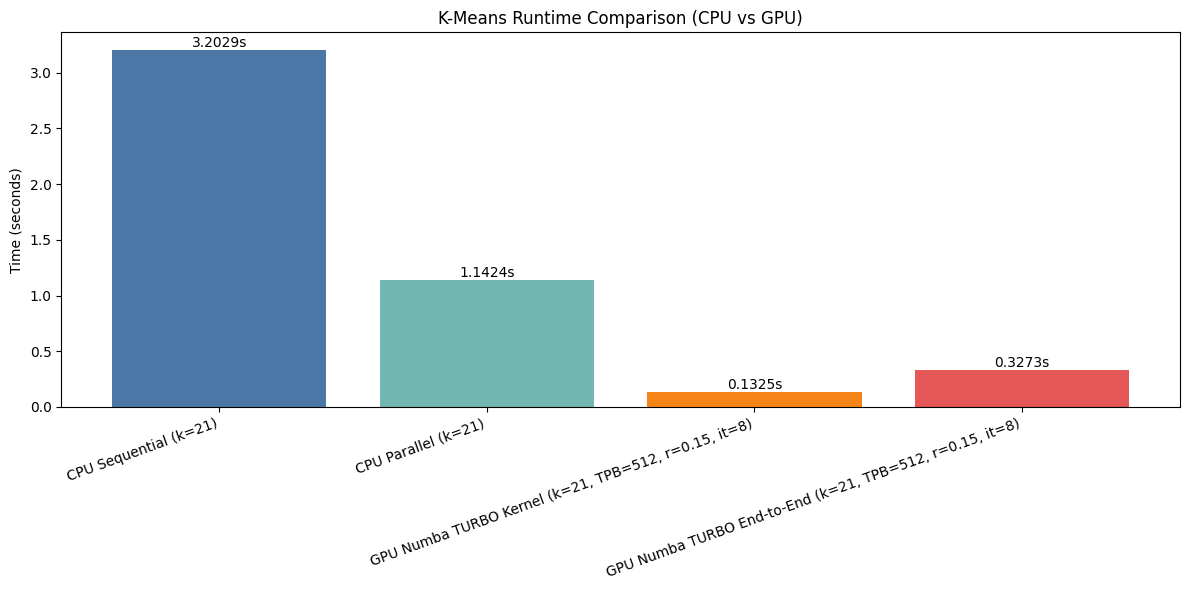

In [19]:
required_vars = ["data", "cpu_time_seq", "cpu_time_parallel"]
missing = [name for name in required_vars if name not in globals()]

final_k = int(globals().get("best_n_clusters", globals().get("n_clusters", 20)))
final_tpb = int(globals().get("best_threads_per_block", 256))
final_ratio = float(globals().get("fastest_ratio", globals().get("best_sample_ratio", 0.25)))
final_max_iter = int(globals().get("fastest_max_iter", 12))

print(
    f"Warming up TURBO GPU with k={final_k}, TPB={final_tpb}, "
    f"ratio={final_ratio:.2f}, max_iter={final_max_iter}..."
)
_ = kmeans_numba_optimized(
    data[:2000],
    n_clusters=final_k,
    max_iter=4,
    threads_per_block=final_tpb,
    convergence_check_every=5,
    mode="turbo",
    sample_ratio=final_ratio,
)

if missing:
    print("Please run the data preparation and CPU benchmark cells first. Missing:", ", ".join(missing))
else:
    numba_start = time.perf_counter()
    numba_result = kmeans_numba_optimized(
        data,
        n_clusters=final_k,
        max_iter=final_max_iter,
        random_state=42,
        threads_per_block=final_tpb,
        convergence_check_every=5,
        mode="turbo",
        sample_ratio=final_ratio,
    )
    numba_wall_time = time.perf_counter() - numba_start

    baseline_seq = cpu_time_seq
    baseline_parallel = cpu_time_parallel

    rows = [
        {
            "Implementation": f"CPU Sequential (k={final_k})",
            "Time (s)": cpu_time_seq,
            "Speedup vs CPU Seq": baseline_seq / cpu_time_seq if cpu_time_seq > 0 else np.nan,
            "Speedup vs CPU Parallel": baseline_parallel / cpu_time_seq if cpu_time_seq > 0 else np.nan,
        },
        {
            "Implementation": f"CPU Parallel (k={final_k})",
            "Time (s)": cpu_time_parallel,
            "Speedup vs CPU Seq": baseline_seq / cpu_time_parallel if cpu_time_parallel > 0 else np.nan,
            "Speedup vs CPU Parallel": baseline_parallel / cpu_time_parallel if cpu_time_parallel > 0 else np.nan,
        },
        {
            "Implementation": (
                f"GPU Numba TURBO Kernel (k={final_k}, TPB={final_tpb}, "
                f"r={final_ratio:.2f}, it={final_max_iter})"
            ),
            "Time (s)": numba_result["gpu_kernel_time_sec"],
            "Speedup vs CPU Seq": baseline_seq / numba_result["gpu_kernel_time_sec"] if numba_result["gpu_kernel_time_sec"] > 0 else np.nan,
            "Speedup vs CPU Parallel": baseline_parallel / numba_result["gpu_kernel_time_sec"] if numba_result["gpu_kernel_time_sec"] > 0 else np.nan,
        },
        {
            "Implementation": (
                f"GPU Numba TURBO End-to-End (k={final_k}, TPB={final_tpb}, "
                f"r={final_ratio:.2f}, it={final_max_iter})"
            ),
            "Time (s)": numba_wall_time,
            "Speedup vs CPU Seq": baseline_seq / numba_wall_time if numba_wall_time > 0 else np.nan,
            "Speedup vs CPU Parallel": baseline_parallel / numba_wall_time if numba_wall_time > 0 else np.nan,
        },
    ]

    comparison_df = pd.DataFrame(rows)
    display_df = comparison_df.copy()
    display_df["Time (s)"] = display_df["Time (s)"].map(lambda x: f"{x:.4f}")
    display_df["Speedup vs CPU Seq"] = display_df["Speedup vs CPU Seq"].map(lambda x: f"{x:.2f}x")
    display_df["Speedup vs CPU Parallel"] = display_df["Speedup vs CPU Parallel"].map(lambda x: f"{x:.2f}x")

    print("\nPerformance Comparison Table")
    print(
        f"Selected turbo config: k={final_k}, TPB={final_tpb}, "
        f"ratio={final_ratio:.2f}, max_iter={final_max_iter}"
    )
    print(f"Work items/iter: {numba_result['work_items_per_iter']}")
    print(display_df.to_string(index=False))

    plt.figure(figsize=(12, 6))
    bars = plt.bar(
        comparison_df["Implementation"],
        comparison_df["Time (s)"],
        color=["#4c78a8", "#72b7b2", "#f58518", "#e45756"],
    )
    plt.title("K-Means Runtime Comparison (CPU vs GPU)")
    plt.ylabel("Time (seconds)")
    plt.xticks(rotation=20, ha="right")

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, h, f"{h:.4f}s", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

    gpu_kernel_time = numba_result["gpu_kernel_time_sec"]
    gpu_end_to_end_time = numba_wall_time
    selected_n_clusters = final_k
    selected_threads_per_block = final_tpb
    selected_sample_ratio = final_ratio
    selected_max_iter = final_max_iter

In [18]:
# Optional: full-dataset speed sweep for absolute fastest turbo settings
if "data" in globals() and "best_n_clusters" in globals() and "best_threads_per_block" in globals():
    sweep_k = int(best_n_clusters)
    sweep_tpb = int(best_threads_per_block)

    ratios = [0.10, 0.15, 0.20, 0.25]
    iters = [8, 10, 12]

    print(f"Full-data speed sweep | k={sweep_k}, TPB={sweep_tpb}")
    sweep_rows = []

    for ratio in ratios:
        for mi in iters:
            t0 = time.perf_counter()
            out = kmeans_numba_optimized(
                data,
                n_clusters=sweep_k,
                max_iter=mi,
                random_state=42,
                threads_per_block=sweep_tpb,
                convergence_check_every=5,
                mode="turbo",
                sample_ratio=ratio,
            )
            wall = time.perf_counter() - t0
            sweep_rows.append((ratio, mi, out["gpu_kernel_time_sec"], wall, out["work_items_per_iter"]))
            print(
                f"ratio={ratio:.2f} | max_iter={mi:>2} | "
                f"kernel={out['gpu_kernel_time_sec']:.4f}s | end-to-end={wall:.4f}s | "
                f"work_items={out['work_items_per_iter']}"
            )

    best_kernel_cfg = min(sweep_rows, key=lambda x: x[2])
    best_wall_cfg = min(sweep_rows, key=lambda x: x[3])

    print("\nBest full-data kernel config:", best_kernel_cfg)
    print("Best full-data end-to-end config:", best_wall_cfg)

    fastest_ratio = float(best_wall_cfg[0])
    fastest_max_iter = int(best_wall_cfg[1])
    print(
        f"Selected fastest full-data settings: ratio={fastest_ratio:.2f}, max_iter={fastest_max_iter}, TPB={sweep_tpb}"
    )
else:
    print("Run preparation/tuning cells first (need data, best_n_clusters, best_threads_per_block).")

Full-data speed sweep | k=21, TPB=512
ratio=0.10 | max_iter= 8 | kernel=0.2008s | end-to-end=0.2043s | work_items=47452


c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 93 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


ratio=0.10 | max_iter=10 | kernel=0.0134s | end-to-end=0.0151s | work_items=47452
ratio=0.10 | max_iter=12 | kernel=0.0087s | end-to-end=0.0102s | work_items=47452
ratio=0.15 | max_iter= 8 | kernel=0.0076s | end-to-end=0.0093s | work_items=71178
ratio=0.15 | max_iter=10 | kernel=0.0092s | end-to-end=0.0106s | work_items=71178
ratio=0.15 | max_iter=12 | kernel=0.0109s | end-to-end=0.0119s | work_items=71178
ratio=0.20 | max_iter= 8 | kernel=0.0092s | end-to-end=0.0106s | work_items=94904
ratio=0.20 | max_iter=10 | kernel=0.0109s | end-to-end=0.0121s | work_items=94904
ratio=0.20 | max_iter=12 | kernel=0.0137s | end-to-end=0.0152s | work_items=94904
ratio=0.25 | max_iter= 8 | kernel=0.0107s | end-to-end=0.0118s | work_items=118631
ratio=0.25 | max_iter=10 | kernel=0.0119s | end-to-end=0.0134s | work_items=118631
ratio=0.25 | max_iter=12 | kernel=0.0179s | end-to-end=0.0192s | work_items=118631

Best full-data kernel config: (0.15, 8, 0.007644800003618002, 0.009325899998657405, 71178)
Bes

In [21]:
# Exact-accuracy tuning (full dataset pass per iteration, fp32 inputs)
exact_candidate_threads = [128, 256, 512]

if "data" not in globals() or "n_clusters" not in globals():
    print("Run the data preparation cells first.")
else:
    tune_rows_exact = min(200000, len(data))
    tune_data_exact = np.ascontiguousarray(data[:tune_rows_exact], dtype=np.float32)
    print(f"Tuning EXACT config on {tune_rows_exact} samples with k={n_clusters}")

    exact_tune_results = []
    for threads_per_block in exact_candidate_threads:
        try:
            start_time = time.perf_counter()
            result_exact = kmeans_numba_optimized(
                tune_data_exact,
                n_clusters=n_clusters,
                max_iter=12,
                random_state=42,
                threads_per_block=threads_per_block,
                convergence_check_every=1,
                mode="exact",
                sample_ratio=1.0,
                precision="fp32",
            )
            wall_time = time.perf_counter() - start_time
            exact_tune_results.append((threads_per_block, result_exact["gpu_kernel_time_sec"], wall_time))
            print(
                f"EXACT | TPB={threads_per_block:>3} | kernel={result_exact['gpu_kernel_time_sec']:.4f}s | "
                f"end-to-end={wall_time:.4f}s"
            )
        except Exception as e:
            print(f"EXACT | TPB={threads_per_block:>3} failed: {e}")

    if exact_tune_results:
        best_exact_kernel = min(exact_tune_results, key=lambda item: item[1])
        best_exact_wall = min(exact_tune_results, key=lambda item: item[2])

        best_threads_per_block_exact = int(best_exact_wall[0])

        print(f"Best EXACT kernel time: TPB={best_exact_kernel[0]} ({best_exact_kernel[1]:.4f}s)")
        print(f"Best EXACT end-to-end time: TPB={best_exact_wall[0]} ({best_exact_wall[2]:.4f}s)")
        print(f"Selected EXACT TPB for final benchmark: {best_threads_per_block_exact}")
    else:
        print("No EXACT configuration completed successfully.")

Tuning EXACT config on 200000 samples with k=21


c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 17 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


EXACT | TPB=128 | kernel=0.7271s | end-to-end=0.8718s
EXACT | TPB=256 | kernel=0.1231s | end-to-end=0.1252s


c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 9 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


EXACT | TPB=512 | kernel=0.1523s | end-to-end=0.1536s
Best EXACT kernel time: TPB=256 (0.1231s)
Best EXACT end-to-end time: TPB=256 (0.1252s)
Selected EXACT TPB for final benchmark: 256


Warming up EXACT GPU with k=21, TPB=256...


c:\Users\elbaz\anaconda3\envs\numba311\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



Exact-Accuracy Performance Comparison Table
Selected exact config: k=21, TPB=256, ratio=1.00, precision=fp32
                            Implementation Time (s) Speedup vs CPU Seq Speedup vs CPU Parallel
                     CPU Sequential (k=21)   3.2029              1.00x                   0.36x
                       CPU Parallel (k=21)   1.1424              2.80x                   1.00x
    GPU Numba EXACT Kernel (k=21, TPB=256)   0.3547              9.03x                   3.22x
GPU Numba EXACT End-to-End (k=21, TPB=256)   0.4716              6.79x                   2.42x


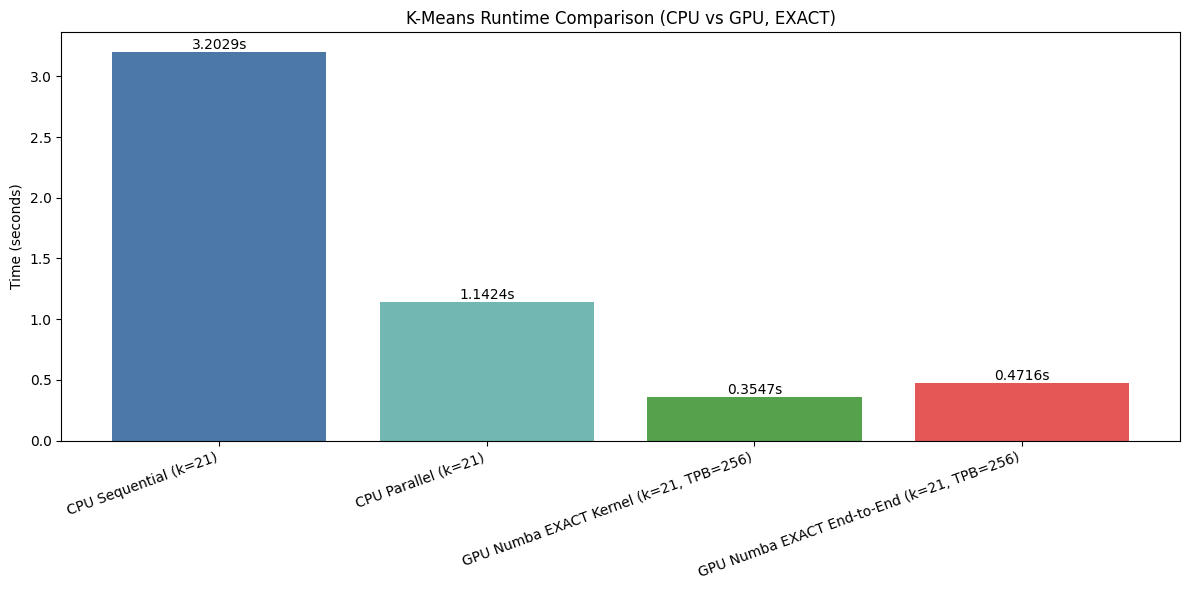

In [22]:
# Exact-accuracy final comparison (no approximation)
required_vars_exact = ["data", "cpu_time_seq", "cpu_time_parallel"]
missing_exact = [name for name in required_vars_exact if name not in globals()]

final_k_exact = int(globals().get("best_n_clusters", globals().get("n_clusters", 20)))
final_tpb_exact = int(globals().get("best_threads_per_block_exact", globals().get("best_threads_per_block", 256)))

print(f"Warming up EXACT GPU with k={final_k_exact}, TPB={final_tpb_exact}...")
_ = kmeans_numba_optimized(
    data[:2000],
    n_clusters=final_k_exact,
    max_iter=4,
    threads_per_block=final_tpb_exact,
    convergence_check_every=1,
    mode="exact",
    sample_ratio=1.0,
    precision="fp32",
)

if missing_exact:
    print("Please run the data preparation and CPU benchmark cells first. Missing:", ", ".join(missing_exact))
else:
    exact_start = time.perf_counter()
    exact_result = kmeans_numba_optimized(
        data,
        n_clusters=final_k_exact,
        max_iter=20,
        random_state=42,
        threads_per_block=final_tpb_exact,
        convergence_check_every=1,
        mode="exact",
        sample_ratio=1.0,
        precision="fp32",
    )
    exact_wall_time = time.perf_counter() - exact_start

    baseline_seq = cpu_time_seq
    baseline_parallel = cpu_time_parallel

    rows_exact = [
        {
            "Implementation": f"CPU Sequential (k={final_k_exact})",
            "Time (s)": cpu_time_seq,
            "Speedup vs CPU Seq": baseline_seq / cpu_time_seq if cpu_time_seq > 0 else np.nan,
            "Speedup vs CPU Parallel": baseline_parallel / cpu_time_seq if cpu_time_seq > 0 else np.nan,
        },
        {
            "Implementation": f"CPU Parallel (k={final_k_exact})",
            "Time (s)": cpu_time_parallel,
            "Speedup vs CPU Seq": baseline_seq / cpu_time_parallel if cpu_time_parallel > 0 else np.nan,
            "Speedup vs CPU Parallel": baseline_parallel / cpu_time_parallel if cpu_time_parallel > 0 else np.nan,
        },
        {
            "Implementation": f"GPU Numba EXACT Kernel (k={final_k_exact}, TPB={final_tpb_exact})",
            "Time (s)": exact_result["gpu_kernel_time_sec"],
            "Speedup vs CPU Seq": baseline_seq / exact_result["gpu_kernel_time_sec"] if exact_result["gpu_kernel_time_sec"] > 0 else np.nan,
            "Speedup vs CPU Parallel": baseline_parallel / exact_result["gpu_kernel_time_sec"] if exact_result["gpu_kernel_time_sec"] > 0 else np.nan,
        },
        {
            "Implementation": f"GPU Numba EXACT End-to-End (k={final_k_exact}, TPB={final_tpb_exact})",
            "Time (s)": exact_wall_time,
            "Speedup vs CPU Seq": baseline_seq / exact_wall_time if exact_wall_time > 0 else np.nan,
            "Speedup vs CPU Parallel": baseline_parallel / exact_wall_time if exact_wall_time > 0 else np.nan,
        },
    ]

    comparison_df_exact = pd.DataFrame(rows_exact)
    display_df_exact = comparison_df_exact.copy()
    display_df_exact["Time (s)"] = display_df_exact["Time (s)"].map(lambda x: f"{x:.4f}")
    display_df_exact["Speedup vs CPU Seq"] = display_df_exact["Speedup vs CPU Seq"].map(lambda x: f"{x:.2f}x")
    display_df_exact["Speedup vs CPU Parallel"] = display_df_exact["Speedup vs CPU Parallel"].map(lambda x: f"{x:.2f}x")

    print("\nExact-Accuracy Performance Comparison Table")
    print(f"Selected exact config: k={final_k_exact}, TPB={final_tpb_exact}, ratio=1.00, precision=fp32")
    print(display_df_exact.to_string(index=False))

    plt.figure(figsize=(12, 6))
    bars_exact = plt.bar(
        comparison_df_exact["Implementation"],
        comparison_df_exact["Time (s)"],
        color=["#4c78a8", "#72b7b2", "#54a24b", "#e45756"],
    )
    plt.title("K-Means Runtime Comparison (CPU vs GPU, EXACT)")
    plt.ylabel("Time (seconds)")
    plt.xticks(rotation=20, ha="right")

    for bar in bars_exact:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, h, f"{h:.4f}s", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

    gpu_kernel_time_exact = exact_result["gpu_kernel_time_sec"]
    gpu_end_to_end_time_exact = exact_wall_time
    selected_n_clusters_exact = final_k_exact
    selected_threads_per_block_exact = final_tpb_exact


Turbo vs Exact Side-by-Side Summary
           Mode GPU Kernel (s) GPU End-to-End (s) Speedup vs CPU Seq (Kernel) Speedup vs CPU Parallel (Kernel)         Accuracy Profile
TURBO (fastest)         0.1325             0.3273                      24.16x                            8.62x Approximate (mini-batch)
          EXACT         0.3547             0.4716                       9.03x                            3.22x            Full-accuracy


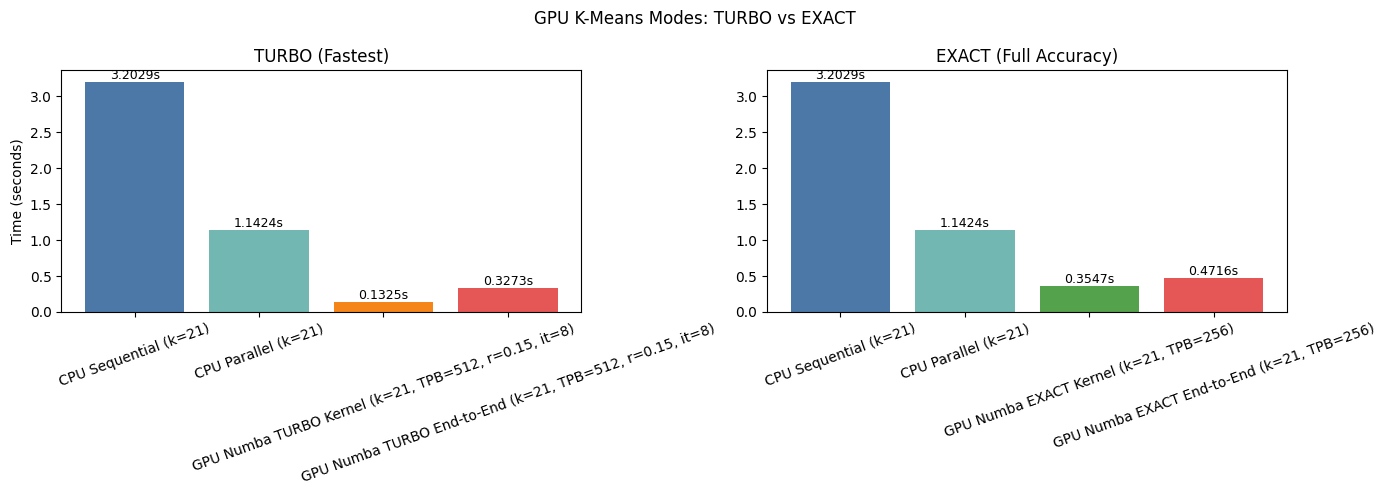

In [23]:
# Turbo vs Exact side-by-side summary
if "comparison_df" not in globals() or "comparison_df_exact" not in globals():
    print("Run both final comparison cells first (TURBO and EXACT) to build the side-by-side summary.")
else:
    turbo_kernel = float(comparison_df.loc[comparison_df["Implementation"].str.contains("Kernel", case=False), "Time (s)"].iloc[0])
    turbo_e2e = float(comparison_df.loc[comparison_df["Implementation"].str.contains("End-to-End", case=False), "Time (s)"].iloc[0])

    exact_kernel = float(comparison_df_exact.loc[comparison_df_exact["Implementation"].str.contains("Kernel", case=False), "Time (s)"].iloc[0])
    exact_e2e = float(comparison_df_exact.loc[comparison_df_exact["Implementation"].str.contains("End-to-End", case=False), "Time (s)"].iloc[0])

    summary_rows = [
        {
            "Mode": "TURBO (fastest)",
            "GPU Kernel (s)": turbo_kernel,
            "GPU End-to-End (s)": turbo_e2e,
            "Speedup vs CPU Seq (Kernel)": cpu_time_seq / turbo_kernel if turbo_kernel > 0 else np.nan,
            "Speedup vs CPU Parallel (Kernel)": cpu_time_parallel / turbo_kernel if turbo_kernel > 0 else np.nan,
            "Accuracy Profile": "Approximate (mini-batch)",
        },
        {
            "Mode": "EXACT",
            "GPU Kernel (s)": exact_kernel,
            "GPU End-to-End (s)": exact_e2e,
            "Speedup vs CPU Seq (Kernel)": cpu_time_seq / exact_kernel if exact_kernel > 0 else np.nan,
            "Speedup vs CPU Parallel (Kernel)": cpu_time_parallel / exact_kernel if exact_kernel > 0 else np.nan,
            "Accuracy Profile": "Full-accuracy",
        },
    ]

    side_by_side_df = pd.DataFrame(summary_rows)

    display_side = side_by_side_df.copy()
    display_side["GPU Kernel (s)"] = display_side["GPU Kernel (s)"].map(lambda x: f"{x:.4f}")
    display_side["GPU End-to-End (s)"] = display_side["GPU End-to-End (s)"].map(lambda x: f"{x:.4f}")
    display_side["Speedup vs CPU Seq (Kernel)"] = display_side["Speedup vs CPU Seq (Kernel)"].map(lambda x: f"{x:.2f}x")
    display_side["Speedup vs CPU Parallel (Kernel)"] = display_side["Speedup vs CPU Parallel (Kernel)"].map(lambda x: f"{x:.2f}x")

    print("\nTurbo vs Exact Side-by-Side Summary")
    print(display_side.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    turbo_plot = comparison_df[["Implementation", "Time (s)"]].copy()
    exact_plot = comparison_df_exact[["Implementation", "Time (s)"]].copy()

    axes[0].bar(turbo_plot["Implementation"], turbo_plot["Time (s)"], color=["#4c78a8", "#72b7b2", "#f58518", "#e45756"])
    axes[0].set_title("TURBO (Fastest)")
    axes[0].set_ylabel("Time (seconds)")
    axes[0].tick_params(axis="x", rotation=20)

    axes[1].bar(exact_plot["Implementation"], exact_plot["Time (s)"], color=["#4c78a8", "#72b7b2", "#54a24b", "#e45756"])
    axes[1].set_title("EXACT (Full Accuracy)")
    axes[1].tick_params(axis="x", rotation=20)

    for ax in axes:
        for p in ax.patches:
            h = p.get_height()
            ax.text(p.get_x() + p.get_width() / 2.0, h, f"{h:.4f}s", ha="center", va="bottom", fontsize=9)

    plt.suptitle("GPU K-Means Modes: TURBO vs EXACT")
    plt.tight_layout()
    plt.show()